<a href="https://colab.research.google.com/github/jigme42/Biomass/blob/main/Training_Machine_Learning_Models_for_AGB_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We first load all the training data, exported in the previous codes in tif format. Our training data entails both Sentinel-1 and Sentinel-2 Indices, as well as elevation data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install rasterio --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 37.7 MB/s eta 0:00:00


In [ ]:
import rasterio
import numpy as np

# Load the AGB tif file
with rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2015.tif') as src:
    agb_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2017.tif') as src:
    agb_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2019.tif') as src:
    agb_2019 = src.read(1)

# Load the elevation data
#with rasterio.open('/content/drive/MyDrive/VI_Exports/Logan_elevation_1m_2017.tif') as src:
    #elevation = src.read(1)

# Load the indices tif filesfor 2016
with rasterio.open('/content/drive/MyDrive/VI_Exports/EVI_2015.tif') as src:
    evi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/LAI_2015.tif') as src:
    lai_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/MSAVI_2015.tif') as src:
    msavi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/NDVI_2015.tif') as src:
    ndvi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/RGR_2015.tif') as src:
    rgr_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/CR_Image_2015.tif') as src:
    cr_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NDPI_Image_2015.tif') as src:
    ndpi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVHI_Image_2015.tif') as src:
    nvhi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVVI_Image_2015.tif') as src:
    nvvi_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/PIRS_Image_2015.tif') as src:
    pirs_2015 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/RVI_Image_2015.tif') as src:
    rvi_2015 = src.read(1)

# 2017 data
with rasterio.open('/content/drive/MyDrive/VI_Exports/EVI_2017.tif') as src:
    evi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/LAI_2017.tif') as src:
    lai_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/MSAVI_2017.tif') as src:
    msavi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/NDVI_2017.tif') as src:
    ndvi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/RGR_2017.tif') as src:
    rgr_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/CR_Image_2017.tif') as src:
    cr_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NDPI_Image_2017.tif') as src:
    ndpi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVHI_Image_2017.tif') as src:
    nvhi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVVI_Image_2017.tif') as src:
    nvvi_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/PIRS_Image_2017.tif') as src:
    pirs_2017 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/RVI_Image_2017.tif') as src:
    rvi_2017 = src.read(1)


# 2019 data
with rasterio.open('/content/drive/MyDrive/VI_Exports/EVI_2019.tif') as src:
    evi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/LAI_2019.tif') as src:
    lai_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/MSAVI_2019.tif') as src:
    msavi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/NDVI_2019.tif') as src:
    ndvi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/VI_Exports/RGR_2019.tif') as src:
    rgr_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/CR_Image_2019.tif') as src:
    cr_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NDPI_Image_2019.tif') as src:
    ndpi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVHI_Image_2019.tif') as src:
    nvhi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/NVVI_Image_2019.tif') as src:
    nvvi_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/PIRS_Image_2019.tif') as src:
    pirs_2019 = src.read(1)
with rasterio.open('/content/drive/MyDrive/S1_Indices_Export/RVI_Image_2019.tif') as src:
    rvi_2019 = src.read(1)


RasterioIOError: ignored

# New Section

In [ ]:
from sklearn.impute import SimpleImputer

# Create datasets by stacking the indices for each epoch
indices_2015 = np.dstack((evi_2015, lai_2015, msavi_2015, ndvi_2015, rgr_2015, cr_2015, ndpi_2015, pirs_2015, rvi_2015))
indices_2017 = np.dstack((evi_2017, lai_2017, msavi_2017, ndvi_2017, rgr_2017, cr_2017, ndpi_2017, pirs_2017, rvi_2017))
indices_2019 = np.dstack((evi_2019, lai_2019, msavi_2019, ndvi_2019, rgr_2019, cr_2019, ndpi_2019, pirs_2019, rvi_2019))

# Flatten the stacked arrays for each epoch
X_2015 = indices_2015.reshape((-1, indices_2015.shape[2]))
X_2017 = indices_2017.reshape((-1, indices_2017.shape[2]))
X_2019 = indices_2019.reshape((-1, indices_2019.shape[2]))

# Flatten the AGB arrays for each epoch
y_2015 = agb_2015.flatten()
y_2017 = agb_2017.flatten()
y_2019 = agb_2019.flatten()




In [ ]:
# Load the 2022 index data
evi_2022 = rasterio.open("/content/drive/MyDrive/VI_Exports/EVI_2022.tif").read(1)
lai_2022 = rasterio.open("/content/drive/MyDrive/VI_Exports/LAI_2022.tif").read(1)
msavi_2022 = rasterio.open("/content/drive/MyDrive/VI_Exports/MSAVI_2022.tif").read(1)
ndvi_2022 = rasterio.open("/content/drive/MyDrive/VI_Exports/NDVI_2022.tif").read(1)
rgr_2022 = rasterio.open("/content/drive/MyDrive/VI_Exports/RGR_2022.tif").read(1)
cr_2022 = rasterio.open("/content/drive/MyDrive/S1_Indices_Export/CR_Image_2022.tif").read(1)
ndpi_2022 = rasterio.open("/content/drive/MyDrive/S1_Indices_Export/NDPI_Image_2022.tif").read(1)
pirs_2022 = rasterio.open("/content/drive/MyDrive/S1_Indices_Export/PIRS_Image_2022.tif").read(1)
rvi_2022 = rasterio.open("/content/drive/MyDrive/S1_Indices_Export/RVI_Image_2022.tif").read(1)

# Create a dataset by stacking the indices
indices_2022 = np.dstack((evi_2022, lai_2022, msavi_2022, ndvi_2022, rgr_2022, cr_2022, ndpi_2022, pirs_2022, rvi_2022))

# Flatten the stacked array
X_2022 = indices_2022.reshape((-1, indices_2022.shape[2]))


In [ ]:
# Replace NaN values with the mean of each column for each epoch
imputer = SimpleImputer(strategy='mean')
X_2015_scaled = imputer.fit_transform(X_2015)
X_2017_scaled = imputer.fit_transform(X_2017)
X_2019_scaled = imputer.fit_transform(X_2019)
X_2022_scaled = imputer.transform(X_2022)

y_2015_imputed = imputer.fit_transform(y_2015.reshape(-1, 1))
y_2017_imputed = imputer.fit_transform(y_2017.reshape(-1, 1))
y_2019_imputed = imputer.fit_transform(y_2019.reshape(-1, 1))

X_train = np.concatenate((X_2015_scaled, X_2017_scaled, X_2019_scaled))
y_train = np.concatenate((y_2015_imputed, y_2017_imputed, y_2019_imputed)).flatten()

<Axes: >

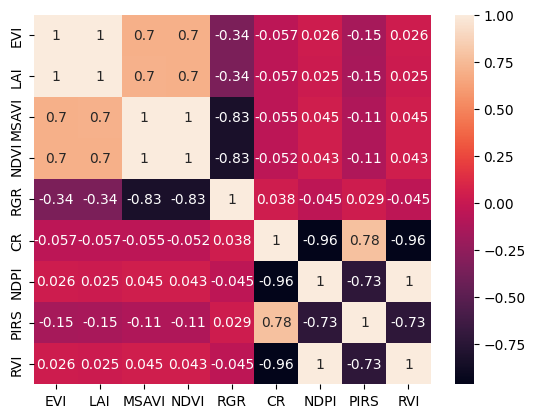

In [ ]:
# Let's run a correlation analysis for the 2016 dataset
import seaborn as sns

# Create a correlation matrix of the indices
corr_matrix = np.corrcoef(X_train.T)

# Create a heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, xticklabels=['EVI', 'LAI', 'MSAVI', 'NDVI', 'RGR', 'CR', 'NDPI', 'PIRS', 'RVI'], yticklabels=['EVI', 'LAI', 'MSAVI', 'NDVI', 'RGR', 'CR', 'NDPI', 'PIRS', 'RVI'])

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Train the model on the concatenated data for the three epochs
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict AGB for 2022
y_2022_pred = model.predict(X_2022_scaled)
y_2022_pred_reshaped = y_2022_pred.reshape(agb_2017.shape[0], -1)

# Save the predicted AGB as a GeoTIFF
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_RF.tif', 'w', driver='Gtiff', width=agb_2017.shape[1], height=agb_2017.shape[0], count=1, dtype=y_2022_pred_reshaped.dtype)
agb_2022_pred_dataset.write(y_2022_pred_reshaped, 1)
agb_2022_pred_dataset.close()


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


In [ ]:
# Let's run the performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Import the SimpleImputer
from sklearn.impute import SimpleImputer

# Load the actual AGB for 2022
agb_2022_actual_dataset = rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2022.tif')
agb_2022_actual = agb_2022_actual_dataset.read(1)

# Load the predicted AGB for 2022
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_RF.tif')
agb_2022_pred = agb_2022_pred_dataset.read(1)

# Flatten the arrays to 1D
agb_2022_actual = agb_2022_actual.flatten()
agb_2022_pred = agb_2022_pred.flatten()

# Impute NaN values with the mean
imputer = SimpleImputer(strategy='mean')
agb_2022_actual = imputer.fit_transform(agb_2022_actual.reshape(-1, 1)).flatten()
#agb_2022_pred = imputer.fit_transform(agb_2022_pred.reshape(-1, 1)).flatten()

# Compute the mean squared error
mse = mean_squared_error(agb_2022_actual, agb_2022_pred)

# Calculate the MAE error
mae = mean_absolute_error(agb_2022_actual, agb_2022_pred)

# Compute the R-squared
r2 = r2_score(agb_2022_actual, agb_2022_pred)

# Print the results
print("RF Results")
print('MSE:', mse)
print('MAE:', mae)
print('R2:', r2)


RF Results
MSE: 0.0004300797231121402
MAE: 0.01143367674523835
R2: 0.6432627757358527


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


**Gradient Boosting Regressor**

In [ ]:
# Import the required libraries
from sklearn.ensemble import GradientBoostingRegressor

# Choose the machine learning model to use
model = GradientBoostingRegressor()


# Train the model on the concatenated data for the three epochs
model.fit(X_train, y_train)

# Predict AGB for 2022
y_2022_pred = model.predict(X_2022_scaled)
y_2022_pred_reshaped = y_2022_pred.reshape(agb_2017.shape[0], -1)

# Save the predicted AGB as a GeoTIFF
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_GBoost.tif', 'w', driver='Gtiff', width=agb_2017.shape[1], height=agb_2017.shape[0], count=1, dtype=y_2022_pred_reshaped.dtype)
agb_2022_pred_dataset.write(y_2022_pred_reshaped, 1)
agb_2022_pred_dataset.close()

# Load the actual AGB for 2022
agb_2022_actual_dataset = rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2022.tif')
agb_2022_actual = agb_2022_actual_dataset.read(1)

# Load the predicted AGB for 2022
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_GBoost.tif')
agb_2022_pred = agb_2022_pred_dataset.read(1)

# Flatten the arrays to 1D
agb_2022_actual = agb_2022_actual.flatten()
agb_2022_pred = agb_2022_pred.flatten()

# Impute NaN values with the mean
imputer = SimpleImputer(strategy='mean')
agb_2022_actual = imputer.fit_transform(agb_2022_actual.reshape(-1, 1)).flatten()
#agb_2022_pred = imputer.fit_transform(agb_2022_pred.reshape(-1, 1)).flatten()

# Compute the mean squared error
mse = mean_squared_error(agb_2022_actual, agb_2022_pred)

# Calculate the MAE error
mae = mean_absolute_error(agb_2022_actual, agb_2022_pred)

# Compute the R-squared
r2 = r2_score(agb_2022_actual, agb_2022_pred)

# Print the results
print("GBoost Results")
print('MSE:', mse)
print('MAE:', mae)
print('R2:', r2)


GBoost Results
MSE: 0.00043048633416780774
MAE: 0.01145096084359675
R2: 0.6429255050124056


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


**Extreme Gradient Boosting**

In [ ]:
# Import the required libraries
from xgboost import XGBRegressor

# Choose the machine learning model to use
model = XGBRegressor()

# Train the model on the concatenated data for the three epochs
model.fit(X_train, y_train)

# Predict AGB for 2022
y_2022_pred = model.predict(X_2022_scaled)
y_2022_pred_reshaped = y_2022_pred.reshape(agb_2017.shape[0], -1)

# Save the predicted AGB as a GeoTIFF
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_XGBoost.tif', 'w', driver='Gtiff', width=agb_2017.shape[1], height=agb_2017.shape[0], count=1, dtype=y_2022_pred_reshaped.dtype)
agb_2022_pred_dataset.write(y_2022_pred_reshaped, 1)
agb_2022_pred_dataset.close()

# Load the actual AGB for 2022
agb_2022_actual_dataset = rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2022.tif')
agb_2022_actual = agb_2022_actual_dataset.read(1)

# Load the predicted AGB for 2022
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_XGBoost.tif')
agb_2022_pred = agb_2022_pred_dataset.read(1)

# Flatten the arrays to 1D
agb_2022_actual = agb_2022_actual.flatten()
agb_2022_pred = agb_2022_pred.flatten()

# Impute NaN values with the mean
imputer = SimpleImputer(strategy='mean')
agb_2022_actual = imputer.fit_transform(agb_2022_actual.reshape(-1, 1)).flatten()
#agb_2022_pred = imputer.fit_transform(agb_2022_pred.reshape(-1, 1)).flatten()

# Compute the mean squared error
mse = mean_squared_error(agb_2022_actual, agb_2022_pred)

# Calculate the MAE error
mae = mean_absolute_error(agb_2022_actual, agb_2022_pred)

# Compute the R-squared
r2 = r2_score(agb_2022_actual, agb_2022_pred)

# Print the results
print("XGBoost Results")
print('MSE:', mse)
print('MAE:', mae)
print('R2:', r2)


XGBoost Results
MSE: 0.0004209643697004502
MAE: 0.01132861313798469
R2: 0.650823666657988


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


**KNN**

In [ ]:
# Import the required libraries
from sklearn.neighbors import KNeighborsRegressor


# Choose the machine learning model to use
model = KNeighborsRegressor()

# Train the model on the concatenated data for the three epochs
model.fit(X_train, y_train)

# Predict AGB for 2022
y_2022_pred = model.predict(X_2022_scaled)
y_2022_pred_reshaped = y_2022_pred.reshape(agb_2017.shape[0], -1)

# Save the predicted AGB as a GeoTIFF
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_KNN.tif', 'w', driver='Gtiff', width=agb_2017.shape[1], height=agb_2017.shape[0], count=1, dtype=y_2022_pred_reshaped.dtype)
agb_2022_pred_dataset.write(y_2022_pred_reshaped, 1)
agb_2022_pred_dataset.close()

# Load the actual AGB for 2022
agb_2022_actual_dataset = rasterio.open('/content/drive/MyDrive/AGB_LAI/AGBlai_2022.tif')
agb_2022_actual = agb_2022_actual_dataset.read(1)

# Load the predicted AGB for 2022
agb_2022_pred_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_KNN.tif')
agb_2022_pred = agb_2022_pred_dataset.read(1)

# Flatten the arrays to 1D
agb_2022_actual = agb_2022_actual.flatten()
agb_2022_pred = agb_2022_pred.flatten()

# Impute NaN values with the mean
imputer = SimpleImputer(strategy='mean')
agb_2022_actual = imputer.fit_transform(agb_2022_actual.reshape(-1, 1)).flatten()
#agb_2022_pred = imputer.fit_transform(agb_2022_pred.reshape(-1, 1)).flatten()

# Compute the mean squared error
mse = mean_squared_error(agb_2022_actual, agb_2022_pred)

# Calculate the MAE error
mae = mean_absolute_error(agb_2022_actual, agb_2022_pred)

# Compute the R-squared
r2 = r2_score(agb_2022_actual, agb_2022_pred)

# Print the results
print("KNN Results")
print('MSE:', mse)
print('MAE:', mae)
print('R2:', r2)


KNN Results
MSE: 0.0004762717752047607
MAE: 0.015178207367481055
R2: 0.6049479620837576


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


**Artificial Neural Network**

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Create an ANN model
model = Sequential()
model.add(Dense(128, input_shape=(9,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Predict AGB for 2022 using the ANN model
y_2022_pred_ann = model.predict(X_2022_scaled)
y_2022_pred_ann_reshaped = y_2022_pred_ann.reshape(agb_2017.shape[0], -1)

# Save the predicted AGB as a GeoTIFF
agb_2022_pred_ann_dataset = rasterio.open('/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_ANN.tif', 'w', driver='Gtiff', width=agb_2017.shape[1], height=agb_2017.shape[0], count=1, dtype=y_2022_pred_ann_reshaped.dtype)
agb_2022_pred_ann_dataset.write(y_2022_pred_ann_reshaped, 1)
agb_2022_pred_ann_dataset.close()

# Compute performance metrics for the ANN model
mse_ann = mean_squared_error(agb_2022_actual, y_2022_pred_ann)
mae_ann = mean_absolute_error(agb_2022_actual, y_2022_pred_ann)
r2_ann = r2_score(agb_2022_actual, y_2022_pred_ann)
print('ANN Model Metrics:')
print('MSE:', mse_ann)
print('MAE:', mae_ann)
print('R2:', r2_ann)


Epoch 1/10
11006/11006 [==============================] - 17s 2ms/step - loss: 8.2681e-05
Epoch 2/10
11006/11006 [==============================] - 17s 2ms/step - loss: 2.1809e-06
Epoch 3/10
11006/11006 [==============================] - 17s 2ms/step - loss: 1.0204e-06
Epoch 4/10
11006/11006 [==============================] - 17s 2ms/step - loss: 7.2287e-07
Epoch 5/10
11006/11006 [==============================] - 17s 2ms/step - loss: 6.1561e-07
Epoch 6/10
11006/11006 [==============================] - 16s 1ms/step - loss: 5.6245e-07
Epoch 7/10
11006/11006 [==============================] - 17s 2ms/step - loss: 5.3289e-07
Epoch 8/10
11006/11006 [==============================] - 16s 1ms/step - loss: 4.9605e-07
Epoch 9/10
11006/11006 [==============================] - 16s 1ms/step - loss: 4.6481e-07
Epoch 10/10
3669/3669 [==============================] - 4s 1ms/step
ANN Model Metrics:
MSE: 0.0004372093268418676
MAE: 0.011427642627881972
R2: 0.6373489999683235


/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


From all the models, XGBoost is the best performing model. Let's visualize it here below, against the actual AGB. We can also try to visualize the next two best models.

/usr/local/lib/python3.9/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


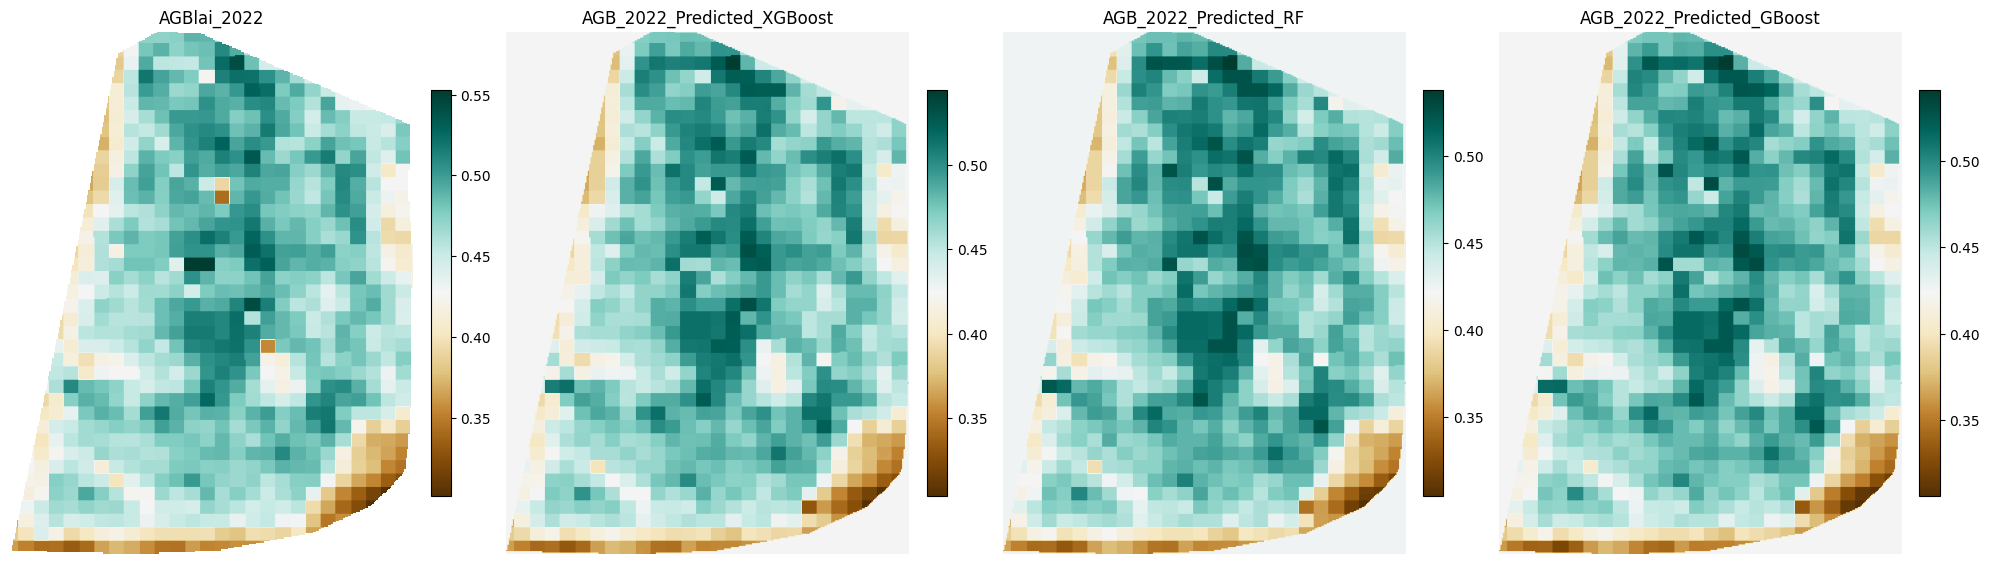

In [ ]:
# Let's visualize the actual 2022 agb against the predicted one
# We can visualize the best three models
import matplotlib.pyplot as plt

# Create a figure with a grid of subplots
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 10))

# List of AGB tifs
tif_paths = ['/content/drive/MyDrive/AGB_LAI/AGBlai_2022.tif',
             '/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_XGBoost.tif',
             '/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_RF.tif',
             '/content/drive/MyDrive/GEE_exports/AGB_2022_Predicted_GBoost.tif']

# Loop through the tifs and plot each one on a subplot
for i, tif_path in enumerate(tif_paths):
    with rasterio.open(tif_path) as src:
        ax = axs.ravel()[i]
        ax.imshow(src.read(1), cmap='BrBG')
        ax.set_title(tif_path.split("/")[-1][0:-4])
        ax.set_axis_off()
        # Add colorbar
        cbar = fig.colorbar(ax.imshow(src.read(1), cmap='BrBG'), ax=ax, fraction=0.046, pad=0.04)
        # Add neat line
        ax.set_frame_on(True)
        ax.axes.get_xaxis().set_visible(True)
        ax.axes.get_yaxis().set_visible(True)

plt.tight_layout()
plt.show()

Based on this visual, there are no major noticeable differences in the predicted AGB. This is possibly because the models perform nearly the same with accuracies ranging in +/-64

In [ ]:
from prettytable import PrettyTable

# Create a table
x = PrettyTable()
x.field_names = ["Model", "R-score", "MAE", "MSE"]

# Add rows to the table
x.add_row(["Random Forest", 64.3263, 0.0114, 0.0004])
x.add_row(["XGBoost", 65.0824, 0.0113, 0.0004])
x.add_row(["Gradient Boosting", 64.2926, 0.0115, 0.0004])
x.add_row(["KNN", 63.7349, 0.0114, 0.0004])
x.add_row(["Support Vector", 60.4948, 0.0152, 0.0005])

# Sort the table by R-score in descending order
x.sortby = "R-score"
x.reversesort = True

# Print the table
print("Model Metrics (sorted by R-score)")
print(x)


Model Metrics (sorted by R-score)
+-------------------+---------+--------+--------+
|       Model       | R-score |  MAE   |  MSE   |
+-------------------+---------+--------+--------+
|      XGBoost      | 65.0824 | 0.0113 | 0.0004 |
|   Random Forest   | 64.3263 | 0.0114 | 0.0004 |
| Gradient Boosting | 64.2926 | 0.0115 | 0.0004 |
|        KNN        | 63.7349 | 0.0114 | 0.0004 |
|   Support Vector  | 60.4948 | 0.0152 | 0.0005 |
+-------------------+---------+--------+--------+


Here we can comfortably access the model performance in decreasing R-score order.